# Decision Trees

A **Decision Tree** is a supervised learning algorithm used for both:

- Classification
- Regression

A decision tree makes predictions by repeatedly splitting the dataset based on feature values.

The tree consists of:

- **Root Node** → Starting point of the tree
- **Decision Nodes** → Conditions used to split the data
- **Branches** → Outcomes of decisions
- **Leaf Nodes** → Final predictions

Example:

        Age <= 30?
        ├── Yes → Student?
        │   ├── Yes → Buy
        │   └── No  → Not Buy
        └── No → Buy

## How Does a Decision Tree Work?

A Decision Tree follows a simple process:

1. Start with the complete training dataset.
2. Select the best feature and split point.
3. Divide the dataset into smaller groups.
4. Repeat the process for each group.
5. Stop when a stopping condition is reached.
6. Use the leaf node to make predictions.

The main goal is to create splits that make the resulting groups as pure as possible.

### Example

Suppose we want to predict whether a person will buy a product.

| Age | Income | Student | Buy |
|---:|---:|---|---|
| 22 | 25 | Yes | Yes |
| 25 | 30 | No | No |
| 28 | 40 | Yes | Yes |
| 35 | 50 | No | Yes |
| 40 | 60 | No | Yes |

The tree may first ask:

    Age <= 30?

Then the data is divided into two groups.

The algorithm continues splitting until useful groups are formed.

## Important Terms

### Root Node
The first node of the tree.

### Internal / Decision Node
A node where a condition is used to split the data.

### Branch
The connection between two nodes.

### Leaf Node
The final node containing the prediction.

### Depth
The maximum number of levels in the tree.

### Split
Dividing the dataset based on a feature and condition.

### Impurity
A measure of how mixed the classes are inside a node.

##  Measuring Node Impurity

For classification, Decision Trees commonly use:

Gini Impurity
Entropy

We will understand both.

## Gini Impurity

Gini Impurity measures how impure a node is.

Formula:

Gini = 1 - Σ pᵢ²

where:

pᵢ = probability of class i

Interpretation:

Gini = 0
→ Completely pure node

Higher Gini
→ More mixed classes

In [1]:
# Calculate Gini Impurity manually

def gini_impurity(probabilities):
    return 1 - sum(p ** 2 for p in probabilities)


# Example:
# 4 samples belong to Class A
# 0 samples belong to Class B

print(gini_impurity([1, 0]))

0


In [2]:
# Example with two classes:
# 50% Class A and 50% Class B

print(gini_impurity([0.5, 0.5]))

0.5


Therefore:

- Gini = 0 → Pure node
- Gini = 0.5 → Maximum impurity for binary classification

## Entropy

Entropy is another measure of impurity.

Formula:

Entropy = -Σ pᵢ log₂(pᵢ)

Interpretation:

Entropy = 0
→ Completely pure node

Higher entropy
→ More uncertainty

In [3]:
import math

def entropy(probabilities):
    result = 0
    
    for p in probabilities:
        if p > 0:
            result -= p * math.log2(p)
    
    return result


# Pure node
print(entropy([1, 0]))

# Completely mixed binary node
print(entropy([0.5, 0.5]))

0.0
1.0


## Information Gain

Information Gain tells us how useful a split is.

Formula:

Information Gain
= Parent Impurity
  - Weighted Child Impurity

A good split produces:

- Low impurity in child nodes
- High Information Gain

The Decision Tree tries to select the split that gives the highest Information Gain.

In [4]:
# Example of Information Gain

parent_entropy = 1.0

left_entropy = 0.0
right_entropy = 0.0

left_weight = 0.5
right_weight = 0.5

weighted_child_entropy = (
    left_weight * left_entropy
    + right_weight * right_entropy
)

information_gain = parent_entropy - weighted_child_entropy

print("Information Gain:", information_gain)

Information Gain: 1.0


## Gini Impurity vs Entropy

Both are used to measure impurity.

| Gini Impurity | Entropy |
|---|---|
| Faster to calculate | Slightly more computationally expensive |
| Common default in scikit-learn | Often used with Information Gain |
| Range: 0 to 0.5 for binary classes | Range: 0 to 1 for binary classes |

In practice, both usually produce similar trees.

## Import Required Libraries

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

## Load Dataset

In [6]:
# Load the Iris dataset

iris = load_iris()

X = iris.data
y = iris.target

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (150, 4)
Target shape: (150,)


In [7]:
# Display feature names

print(iris.feature_names)

['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']


In [8]:
# Display target names

print(iris.target_names)

['setosa' 'versicolor' 'virginica']


The Iris dataset contains four features:

1. Sepal length
2. Sepal width
3. Petal length
4. Petal width

The target contains three classes:

- Setosa
- Versicolor
- Virginica

## Create DataFrame

In [9]:
df = pd.DataFrame(
    X,
    columns=iris.feature_names
)

df["target"] = y

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


## Split the Dataset

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 120
Testing samples: 30


## Training the Decision Tree

We will use `DecisionTreeClassifier` from scikit-learn.

For the first model, we will use:

- `criterion="gini"`
- `max_depth=3`

`max_depth` controls how deep the tree can grow.

In [11]:
# Create the Decision Tree model

model = DecisionTreeClassifier(
    criterion="gini",
    max_depth=3,
    random_state=42
)

# Train the model
model.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current no

## Make Predictions

In [12]:
# Predict the test data

y_pred = model.predict(X_test)

print(y_pred)

[0 2 1 1 0 1 0 0 2 1 2 2 2 1 0 0 0 1 1 2 0 2 1 2 2 2 1 0 2 0]


## Evaluate the Model

In [13]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.9666666666666667


Accuracy tells us the percentage of test samples classified correctly.

Accuracy = Correct Predictions / Total Predictions

## Predict a New Sample

In [14]:
# Example new flower

new_flower = [[5.1, 3.5, 1.4, 0.2]]

prediction = model.predict(new_flower)

print("Predicted class:", iris.target_names[prediction][0])

Predicted class: setosa


## Visualize the Decision Tree

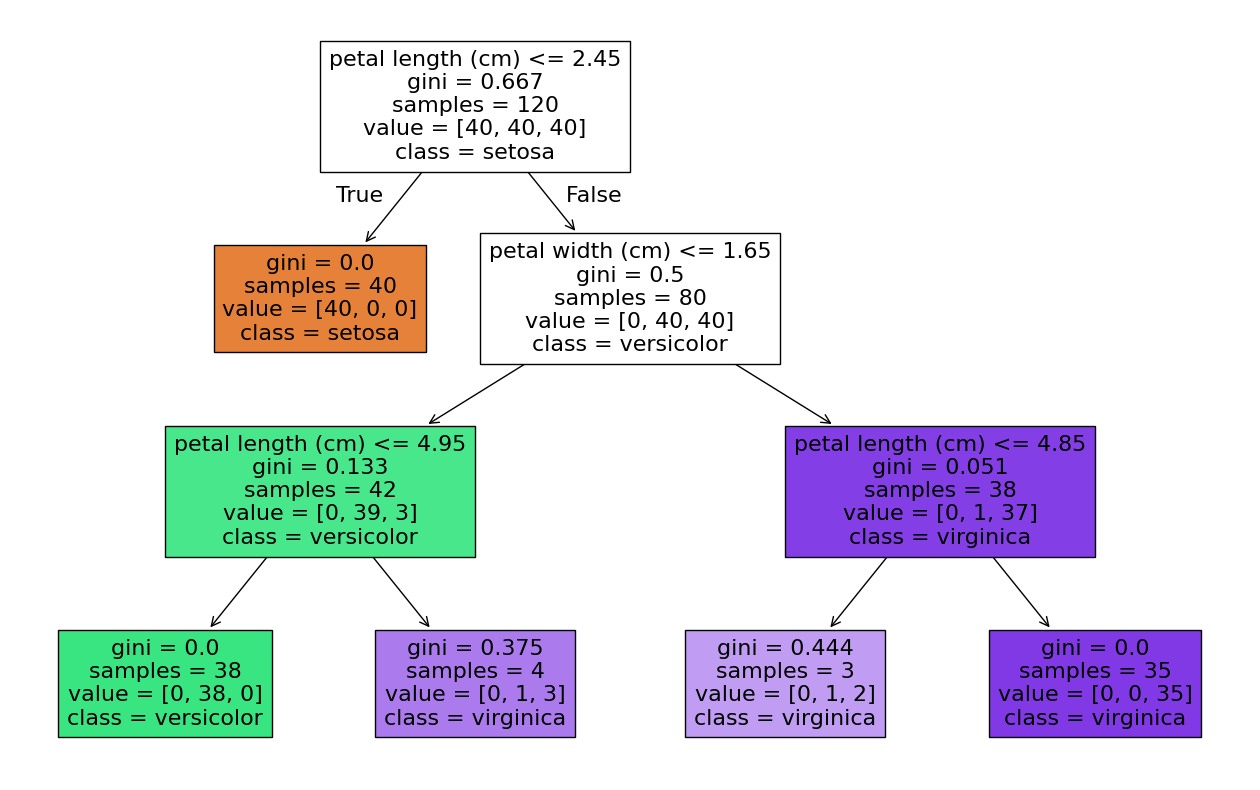

In [15]:
from sklearn.tree import plot_tree

plt.figure(figsize=(16, 10))

plot_tree(
    model,
    feature_names=iris.feature_names,
    class_names=iris.target_names,
    filled=True
)

plt.show()

The visualization shows how the Decision Tree makes decisions.

Each node contains information such as:

- Feature used for splitting
- Threshold
- Gini impurity
- Number of samples
- Class distribution

## Effect of Tree Depth

`max_depth` controls the maximum depth of the tree.
```text
Small depth:
    → Simple model
    → May underfit

Very large depth:
    → Complex model
    → May overfit

Therefore, controlling tree depth is important.

In [16]:
depths = range(1, 11)

train_accuracy = []
test_accuracy = []

for depth in depths:
    
    tree = DecisionTreeClassifier(
        max_depth=depth,
        random_state=42
    )
    
    tree.fit(X_train, y_train)
    
    train_accuracy.append(
        tree.score(X_train, y_train)
    )
    
    test_accuracy.append(
        tree.score(X_test, y_test)
    )

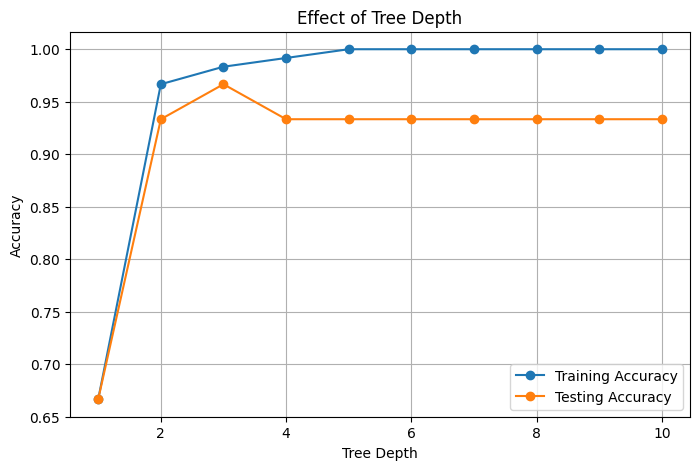

In [17]:
plt.figure(figsize=(8, 5))

plt.plot(depths, train_accuracy, marker="o", label="Training Accuracy")
plt.plot(depths, test_accuracy, marker="o", label="Testing Accuracy")

plt.xlabel("Tree Depth")
plt.ylabel("Accuracy")
plt.title("Effect of Tree Depth")
plt.legend()
plt.grid()

plt.show()

## Overfitting

Decision Trees can easily become very complex.

If a tree grows too deep, it can memorize the training data instead of learning general patterns.

This causes:

Training Accuracy → Very high

Testing Accuracy → Lower

This is called **overfitting**.

Common ways to control overfitting:

- `max_depth`
- `min_samples_split`
- `min_samples_leaf`
- `max_leaf_nodes`
- Pruning

## Important Decision Tree Hyperparameters

### max_depth
Maximum depth of the tree.

### min_samples_split
Minimum number of samples required to split a node.

### min_samples_leaf
Minimum number of samples required in a leaf.

### max_leaf_nodes
Maximum number of leaf nodes.

### criterion
Function used to measure the quality of a split.

Common values:

- `"gini"`
- `"entropy"`
- `"log_loss"`

## Decision Tree with Different Criteria

In [18]:
# Decision Tree using Gini

tree_gini = DecisionTreeClassifier(
    criterion="gini",
    max_depth=3,
    random_state=42
)

tree_gini.fit(X_train, y_train)

print(
    "Gini Accuracy:",
    tree_gini.score(X_test, y_test)
)

Gini Accuracy: 0.9666666666666667


In [19]:
# Decision Tree using Entropy

tree_entropy = DecisionTreeClassifier(
    criterion="entropy",
    max_depth=3,
    random_state=42
)

tree_entropy.fit(X_train, y_train)

print(
    "Entropy Accuracy:",
    tree_entropy.score(X_test, y_test)
)

Entropy Accuracy: 0.9666666666666667


## Feature Importance

Decision Trees can tell us how important each feature was when making decisions.

The values are available through:

    model.feature_importances_

In [20]:
feature_importance = pd.DataFrame({
    "Feature": iris.feature_names,
    "Importance": model.feature_importances_
})

feature_importance.sort_values(
    by="Importance",
    ascending=False
)

,Feature,Importance
2,petal length (cm),0.579077
3,petal width (cm),0.420923
1,sepal width (cm),0.000000
0,sepal length (cm),0.000000


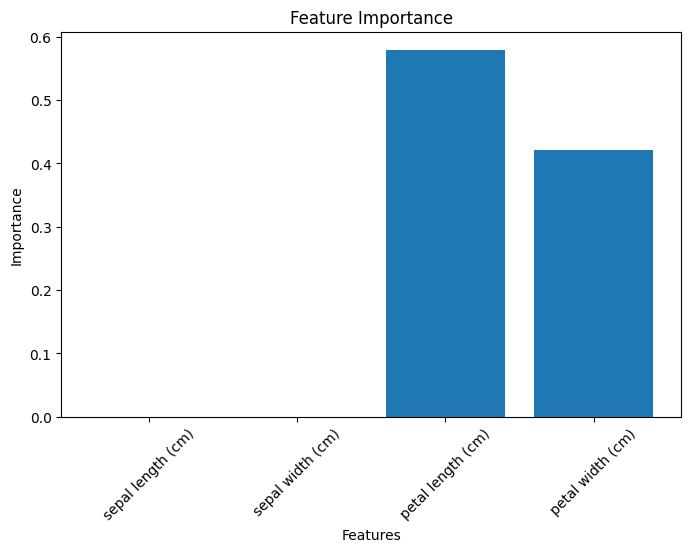

In [21]:
plt.figure(figsize=(8, 5))

plt.bar(
    iris.feature_names,
    model.feature_importances_
)

plt.xlabel("Features")
plt.ylabel("Importance")
plt.title("Feature Importance")

plt.xticks(rotation=45)
plt.show()

## Decision Tree Workflow

```text
The complete workflow is:

Data
 ↓
Train-Test Split
 ↓
Choose Criterion
 ↓
Find Best Split
 ↓
Build Decision Tree
 ↓
Control Tree Complexity
 ↓
Make Predictions
 ↓
Evaluate Model

## Does Decision Tree Require Feature Scaling?

No.

Decision Trees generally **do not require feature scaling**.

For example, unlike KNN or Logistic Regression, we do not need to standardize the features before training a Decision Tree.

The tree makes decisions using conditions such as:

    Petal length <= 2.45

Therefore, the model is not dependent on the scale of the features.

## Advantages

- Easy to understand
- Easy to visualize
- Works with numerical and categorical features
- Does not require feature scaling
- Can model non-linear relationships
- Provides feature importance

## Disadvantages

- Can easily overfit
- Small changes in data can produce a different tree
- Deep trees can become complicated
- Individual trees are often less stable than ensemble methods

# Summary

In this notebook, we learned:

- What Decision Trees are
- Root, decision and leaf nodes
- How tree splitting works
- Gini Impurity
- Entropy
- Information Gain
- Training a Decision Tree classifier
- Making predictions
- Evaluating accuracy
- Visualizing a Decision Tree
- Controlling tree depth
- Overfitting
- Important hyperparameters
- Feature importance
- Why feature scaling is generally unnecessary

### Key Idea

A Decision Tree repeatedly asks questions about features
to divide the data into increasingly pure groups until
it reaches a final prediction.